In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class Node:
    def __init__(self, name, phi=0.5, noise_std=1.0):
        self.name = name
        self.parents = []
        self.phi = phi
        self.noise_std = noise_std
        self.beta = {}

    def add_parent(self, parent, beta):
        self.parents.append(parent)
        self.beta[parent.name] = beta


class DynamicCausalDAG:
    def __init__(self):
        self.nodes = {}

    def add_node(self, name, phi=0.5, noise_std=1.0):
        self.nodes[name] = Node(name, phi, noise_std)

    def add_edge(self, parent, child, beta=0.8):
        self.nodes[child].add_parent(self.nodes[parent], beta)

    def node_names(self):
        return list(self.nodes.keys())


def build_dag_from_dict(edge_dict, phi=0.5, noise_std=1.0):
    dag = DynamicCausalDAG()

    nodes = set(edge_dict.keys())
    for children in edge_dict.values():
        nodes.update(children)

    for node in nodes:
        dag.add_node(node, phi=phi, noise_std=noise_std)

    for parent, children in edge_dict.items():
        for child in children:
            dag.add_edge(parent, child)

    return dag


def simulate_dlm(dag, T=50, seed=0):
    np.random.seed(seed)
    names = dag.node_names()
    data = {name: np.zeros(T) for name in names}

    for t in range(1, T):
        for name in names:
            node = dag.nodes[name]

            x = node.phi * data[name][t - 1]

            for parent in node.parents:
                x += node.beta[parent.name] * data[parent.name][t - 1]

            x += np.random.normal(0, node.noise_std)
            data[name][t] = x

    return pd.DataFrame(data)

def plot_dag(dag):
    names = dag.node_names()
    n = len(names)

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    positions = {
        name: (np.cos(a), np.sin(a))
        for name, a in zip(names, angles)
    }

    plt.figure(figsize=(6, 6))

    # Plot nodes
    for name, (x, y) in positions.items():
        plt.scatter(x, y, s=1200)
        plt.text(x, y, name, ha='center', va='center', fontsize=12, color='white')

    # Plot edges
    for child in dag.nodes.values():
        for parent in child.parents:
            x1, y1 = positions[parent.name]
            x2, y2 = positions[child.name]
            plt.arrow(
                x1, y1,
                0.85 * (x2 - x1),
                0.85 * (y2 - y1),
                head_width=0.05,
                length_includes_head=True
            )

    plt.title("DAG Causal")
    plt.axis("off")
    plt.show()
    
    
def plot_time_series(df):
    n = df.shape[1]
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, df.columns):
        ax.plot(df[col])
        ax.set_title(col)
        ax.grid(True)

    plt.xlabel("Tempo")
    plt.tight_layout()
    plt.show()

def save_simulation(df, dag, filename="simulation.csv"):
    edge_list = []

    for child in dag.nodes.values():
        for parent in child.parents:
            edge_list.append(f"{parent.name}->{child.name}")

    df_out = df.copy()
    df_out.attrs["DAG"] = ", ".join(edge_list)

    df_out.to_csv(filename, index=False)
    print(f"Arquivo salvo em: {filename}")
    print("DAG:", df_out.attrs["DAG"])
    
    


In [3]:

edges = {
    "A": ["B"],
    "B": ["C", "D"]
}

dag = build_dag_from_dict(edges, phi=0.6, noise_std=0.5)

df = simulate_dlm(dag, T=100, seed=42)



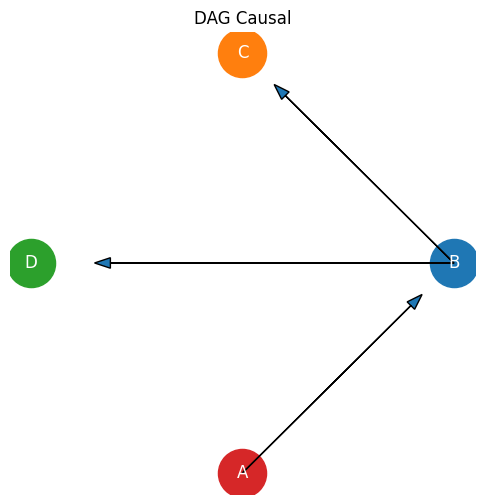

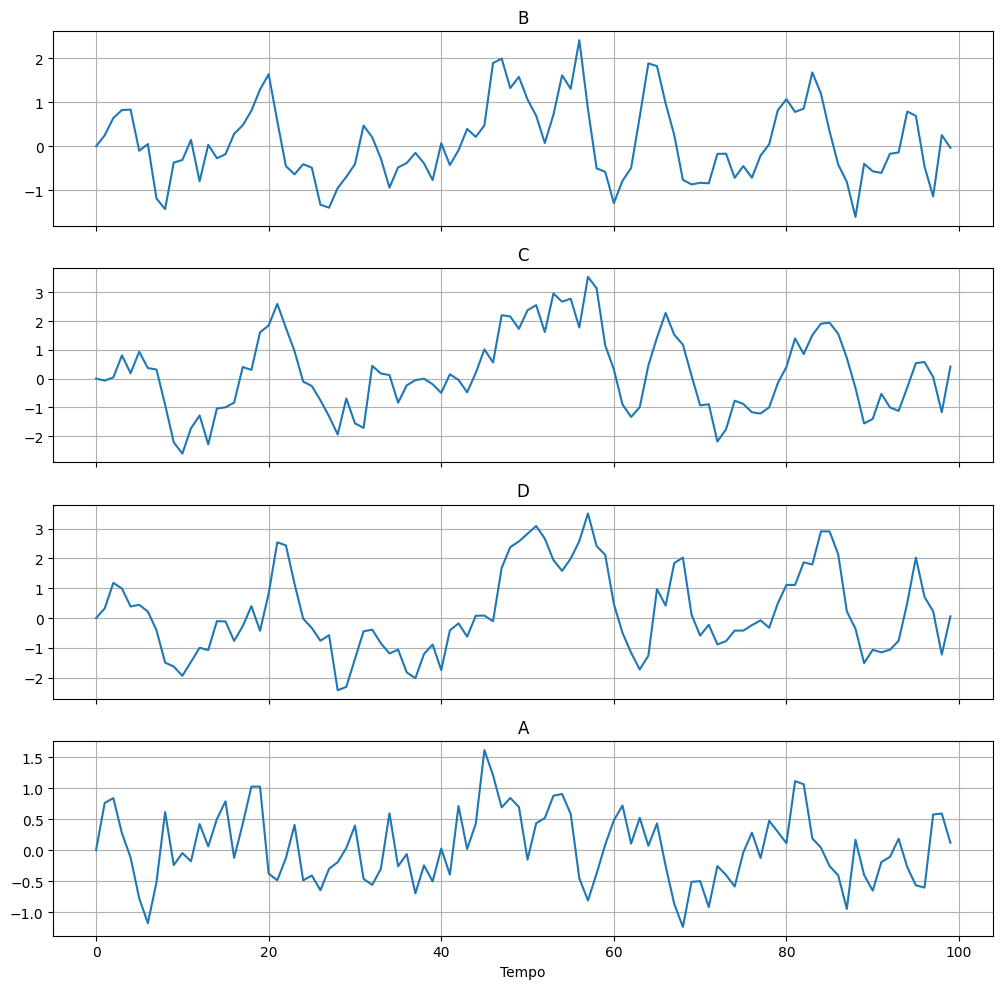

In [4]:
plot_dag(dag)
plot_time_series(df)



In [5]:
save_simulation(df, dag, filename="simulated_dag_time_series.csv")

Arquivo salvo em: simulated_dag_time_series.csv
DAG: A->B, B->C, B->D
